In [153]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import sage.all as sage
from sage.all import sin, cos, pi, ln, diff
from ic_generator import generate_ic_grid, get_ic_grid_info
from state_helpers import StateAccessor
from ode_viewer_nD import ODESystemND, ODEViewerND

In [154]:
# CONFIGURATION

N_VARS = 3  # Number of variables

# --- Numerical Settings ---
t_start = -20.0  # Start time
t_end = 30.0  # End time
num_points = 1000  # Number of points for trajectory (higher = smoother)
step_size = 0.01  # Integration step size

max_boundary = 50  # Maximum axis limit for plot boundaries (None = auto)
compute_boundary = 2 * max_boundary if max_boundary else None  # Stop computation when values exceed this

# --- Initial Conditions (automatically scales with N_VARS) ---
# Format is always [t, x, y, z, ...]
IC_CENTER = [1.0, 0.0, 0.0]  # Center of initial condition grid
IC_SPREAD = [2, 2, 2]  # Spread around center (by unit)
ICS_PER_VAR = [2, 2, 2]  # Number of ICs along each dimension

# --- Projection Settings ---
# Which 3 variables to use as (x_axis, y_axis, z_axis) in the 3D plot
# 0 = time, 1 = first var, 2 = second var, 3 = third var, ...
projection_axes = [1, 2, 3]  # Works for any N_VARS (len MUST equal 3)
color_by = 0  # Which variable to color by (0 = t, 1 = x, 2 = y, ...) or None

# --- Display Settings ---
figsize = (10, 8)  # Figure size (width, height)
title = "Phase Space"  # Plot title

# --- Output Settings ---
save_plot = True  # Save the plot to a file
save_path = "./Plots/3D/3D_NSYS_ODE.png"

# --- Live Viewer Settings ---
use_threejs = True
threejs_filename = "./Plots/3D/3D_NSYS_ODE.html"

# --- Color Settings ---
# Colormap for trajectories and color bar
# Options: "viridis", "plasma", "inferno", "coolwarm", "RdYlBu", "twilight", etc.
colormap_name = "viridis"  # Easy to distinguish start and end

In [155]:
# SYSTEM DEFINITION

# Example: Each variable's derivative is sine of the next variable
# derivs = []
# for i in range(N_VARS):
#     next_idx = (i + 1) % N_VARS
#     derivs.append(sin(state[next_idx]))
# return derivs # return dⁿx/dtⁿ

# Alternatively, use StateAccessor for named access:
# s = StateAccessor(state, VAR_NAMES)
# dx = sin(s.x_1) if N_VARS > 1 else 0
# dy = sin(s.x_2) if N_VARS > 2 else 0
# dz = sin(s.x_0)
# return [dx, dy, dz] # return [dx₁/dt, dx₂/dt, ...]

first_order_system = False  # Set to True for first-order systems like Lorenz
ode_order = N_VARS if not first_order_system else None

if first_order_system:
    # First-order system: define dx/dt for each variable
    # Generate variables
    VAR_NAMES = [f"x_{i}" if i > 0 else "x" for i in range(N_VARS)]

    def system_func(t, state):
        # state = [dx₁/dt, dx₂/dt, ...]
        s = StateAccessor(state, VAR_NAMES)

        p = 10
        r = 28
        b = 8 / 3

        dx = p * (s.x_1 - s.x)
        dy = s.x * (r - s.x_2) - s.x_1
        dz = s.x * s.x_1 - b * s.x_2

        return [dx, dy, dz]

else:
    # Higher-order system: define dⁿx/dtⁿ
    VAR_NAMES = ["x"] + [("d" * i) + "x" for i in range(1, ode_order)]

    def highest_derivative(t, state):
        # state = [x, dx/dt, d²x/dt², ..., dⁿ⁻¹x/dtⁿ⁻¹]
        s = StateAccessor(state, VAR_NAMES)

        return -s.ddx - s.x + s.x ** 2 - 1

In [156]:
# GENERATE INITIAL CONDITIONS

ic_grid = generate_ic_grid(N_VARS, IC_CENTER, IC_SPREAD, ICS_PER_VAR)
total_ics = get_ic_grid_info(N_VARS, ICS_PER_VAR)

print(f"System: {N_VARS}-variable system")
print(f"Variables: {VAR_NAMES}")
print(f"Initial conditions: {total_ics} trajectories")
print(f"IC grid: {len(ic_grid)} total points")
print(f"Time span: [{t_start}, {t_end}]")
print()

System: 3-variable system
Variables: ['x', 'dx', 'ddx']
Initial conditions: 8 trajectories
IC grid: 8 total points
Time span: [-20.0, 30.0]



Completed trajectory 1 of 8
Completed trajectory 2 of 8
Completed trajectory 3 of 8
Completed trajectory 4 of 8
Completed trajectory 5 of 8
Completed trajectory 6 of 8
Completed trajectory 7 of 8
Completed trajectory 8 of 8
✓ Solved 8 trajectories


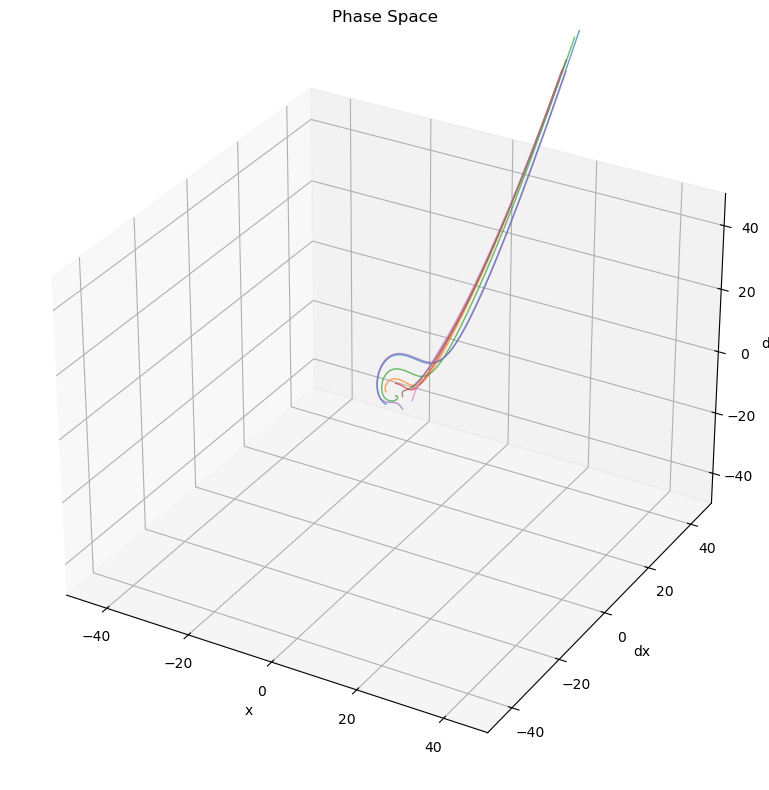

✓ Plotted phase space with projection axes [1, 2, 3]


In [157]:
# RUNNING AND PLOTTING

if first_order_system:
    system = ODESystemND(system_func, N_VARS, VAR_NAMES)
else:
    system = ODESystemND.from_higher_order(highest_derivative, ode_order, VAR_NAMES)

t_eval = np.linspace(t_start, t_end, num_points)
viewer = ODEViewerND()

viewer.solve_ics_grid(
    system,
    (t_start, t_end),
    ic_grid,
    total_ics,
    t_eval=t_eval,
)

print(f"✓ Solved {len(viewer.solutions)} trajectories")

viewer.plot_all_3d(
    projection_axes=projection_axes,
    color_variable=color_by,
    figsize=figsize,
    title=title,
    save_path=save_path if save_plot else None,
    max_boundary=max_boundary,
    compute_boundary=compute_boundary,
)

print(f"✓ Plotted phase space with projection axes {projection_axes}")

In [ ]:
# THREE.JS INTERACTIVE VIEWER

if use_threejs:
    cmap = cm.get_cmap(colormap_name)
    
    def norm_to_rgb(norm_val):
        rgba = cmap(norm_val)
        return tuple(rgba[:3])  # Return (R, G, B) as 0-1 floats
    
    def rgb_to_hex(rgb):
        r, g, b = [int(round(x * 255)) for x in rgb]
        return f"#{r:02x}{g:02x}{b:02x}"
    
    traj_data = viewer.get_threejs_trajectories(
        projection_axes=projection_axes,
        color_variable=color_by,
        compute_boundary=compute_boundary,
    )

    plot_obj = sage.Graphics()

    all_color_values = []
    if color_by is not None:
        for traj in traj_data:
            if traj.get("color_values"):
                all_color_values.extend(traj["color_values"])

    for idx, traj in enumerate(traj_data):
        points = traj["points"]

        if color_by is not None and traj.get("normalized_colors") is not None:
            colors = traj["normalized_colors"]
            for i in range(0, len(points) - 1):
                color_val = colors[i]
                rgb = norm_to_rgb(color_val)
                segment = sage.line3d(
                    [points[i], points[i + 1]],
                    color=rgb_to_hex(rgb),
                    thickness=2,
                    opacity=0.8,
                )
                plot_obj += segment
        else:
            traj_color = traj.get("trajectory_color", 0)
            rgb = norm_to_rgb(traj_color)
            line = sage.line3d(
                points,
                color=rgb_to_hex(rgb),
                thickness=2,
                opacity=0.8,
            )
            plot_obj += line
        print(f"Completed trajectory {idx + 1} of {len(traj_data)}")
    
    if color_by is not None and all_color_values:
        c_min = min(all_color_values)
        c_max = max(all_color_values)
        color_label = VAR_NAMES[color_by - 1] if 0 < color_by <= N_VARS else 'time'
        
        pos_base = compute_boundary * 0.7 if compute_boundary else 50
        bar_x = pos_base
        bar_y = pos_base
        bar_z_start = -30
        bar_z_end = 30
        bar_length = bar_z_end - bar_z_start
        
        n_segments = 20
        for i in range(n_segments):
            norm_val = i / (n_segments - 1) if n_segments > 1 else 0
            z_pos = bar_z_start + norm_val * bar_length
            z_next = bar_z_start + ((i + 1) / (n_segments - 1)) * bar_length if i < n_segments - 1 else bar_z_end
            
            rgb = norm_to_rgb(norm_val)
            segment = sage.line3d(
                [[bar_x, bar_y, z_pos], [bar_x, bar_y, z_next]],
                color=rgb_to_hex(rgb),
                thickness=10,
            )
            plot_obj += segment
        
        plot_obj += sage.text3d(color_label, (bar_x - 10, bar_y + 10, bar_z_end + 5), fontsize=12, color='black')
        plot_obj += sage.text3d(f"{c_max:.2e}", (bar_x - 10, bar_y + 10, bar_z_end - 3), fontsize=10, color='black')
        plot_obj += sage.text3d(f"{c_min:.2e}", (bar_x - 10, bar_y + 10, bar_z_start + 3), fontsize=10, color='black')
        
        print(f"Color by: {color_by} ({color_label}), range: [{c_min:.2e}, {c_max:.2e}]")
        print(f"Colormap: {colormap_name}")
    elif color_by is not None:
        print(f"Color by: {color_by} ({VAR_NAMES[color_by-1] if 0 < color_by <= N_VARS else 'time'})")

    plot_obj.save(threejs_filename, viewer="threejs", online=True)
    print(f"✓ Three.js plot saved to: {threejs_filename}")
    sage.show(plot_obj)
else:
    print("Three.js viewer not set to True")

Completed trajectory 1 of 8
Completed trajectory 2 of 8
Completed trajectory 3 of 8
Completed trajectory 4 of 8
Completed trajectory 5 of 8
Completed trajectory 6 of 8
Completed trajectory 7 of 8
Completed trajectory 8 of 8
Color by: 0 (time), range: [-2.00e+01, -1.29e+01]
Colormap: viridis
✓ Three.js plot saved to: ./Plots/3D/3D_NSYS_ODE.html
Graphics3d Object


/var/folders/3j/5z92g6nn29n86z0mwbtybwc00000gn/T/ipykernel_43985/1363575880.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap_name)
